# Zero Density in Symmetric-Group Character Tables

This notebook plots the density of zero entries in character tables of `S_n`.

- Small values of `n` are computed directly with `murnaghan_nakayama.get_character_table`.
- The `S_40` value is computed by streaming `runs/S40/S40.csv` or `runs/S40/S40.csv.gz`, so the full 4.6 GB table is never loaded into memory.
- Zero density means `number of zero entries / total number of entries`.

In [8]:
from pathlib import Path
import csv
import gzip
import time

import matplotlib.pyplot as plt
import numpy as np

import murnaghan_nakayama as mn

## Configuration

Increase `SMALL_N_MAX` if your machine can compute more direct tables. The default computes through `S_14`, which is still small enough for ordinary laptops. The notebook looks for the large `S_40` file directly under the repository root first, matching the VM layout you described.


In [ ]:
SMALL_N_MAX = 25
INCLUDE_S40 = True
S40_CANDIDATES = [
    Path("S40.csv.gz"),
    Path("S40.csv"),
    Path("runs/S40/S40.csv.gz"),
    Path("runs/S40/S40.csv"),
]
CSV_PROGRESS_INTERVAL = 1000


## Helper functions

In [10]:
def open_text_maybe_gzip(path):
    if str(path).endswith(".gz"):
        return gzip.open(path, "rt", newline="")
    return open(path, "r", newline="")


def zero_density_array(table):
    zero_count = int(np.count_nonzero(table == 0))
    total_count = int(table.size)
    return {
        "zero_count": zero_count,
        "total_count": total_count,
        "density": zero_count / total_count,
    }


def zero_density_csv(path, expected_size=None, progress_interval=1000):
    path = Path(path)
    zero_count = 0
    total_count = 0
    rows = 0
    width = None
    start = time.perf_counter()

    with open_text_maybe_gzip(path) as file:
        reader = csv.reader(file)
        for row in reader:
            rows += 1
            if width is None:
                width = len(row)
            elif len(row) != width:
                raise ValueError(
                    f"Ragged row {rows}: expected {width} columns, found {len(row)}"
                )

            total_count += len(row)
            zero_count += sum(1 for value in row if value.strip() == "0")

            if progress_interval and rows % progress_interval == 0:
                elapsed = time.perf_counter() - start
                if expected_size:
                    percent = 100 * rows / expected_size
                    print(
                        f"{path.name}: {rows}/{expected_size} rows "
                        f"({percent:.1f}%), elapsed {elapsed:.1f}s"
                    )
                else:
                    print(f"{path.name}: {rows} rows, elapsed {elapsed:.1f}s")

    if expected_size is not None and rows != expected_size:
        raise ValueError(f"Expected {expected_size} rows, found {rows}")
    if expected_size is not None and width != expected_size:
        raise ValueError(f"Expected {expected_size} columns, found {width}")

    elapsed = time.perf_counter() - start
    return {
        "zero_count": zero_count,
        "total_count": total_count,
        "density": zero_count / total_count,
        "rows": rows,
        "columns": width,
        "elapsed_seconds": elapsed,
        "path": str(path),
    }


def find_first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None

## Compute densities for directly computed `n`

These tables are computed directly. With `SMALL_N_MAX = 14`, this gives a denser set of points before the streamed `S_40` value. The row and column ordering does not affect zero density.


In [16]:
results = []

for n in range(1, SMALL_N_MAX + 1):
    start = time.perf_counter()
    mn.clear_caches()
    table = mn.get_character_table(n, memo_file_name="")
    stats = zero_density_array(table)
    elapsed = time.perf_counter() - start
    results.append({"n": n, "source": "computed", "elapsed_seconds": elapsed, **stats})
    print(
        f"S_{n}: p(n)={table.shape[0]}, zeros={stats['zero_count']}/"
        f"{stats['total_count']}, density={stats['density']:.6f}, elapsed={elapsed:.2f}s"
    )

S_1: p(n)=1, zeros=0/1, density=0.000000, elapsed=0.01s
S_2: p(n)=2, zeros=0/4, density=0.000000, elapsed=0.00s
S_3: p(n)=3, zeros=1/9, density=0.111111, elapsed=0.00s
S_4: p(n)=5, zeros=4/25, density=0.160000, elapsed=0.00s
S_5: p(n)=7, zeros=10/49, density=0.204082, elapsed=0.00s
S_6: p(n)=11, zeros=29/121, density=0.239669, elapsed=0.00s
S_7: p(n)=15, zeros=55/225, density=0.244444, elapsed=0.00s
S_8: p(n)=22, zeros=153/484, density=0.316116, elapsed=0.00s
S_9: p(n)=30, zeros=307/900, density=0.341111, elapsed=0.00s
S_10: p(n)=42, zeros=588/1764, density=0.333333, elapsed=0.00s
S_11: p(n)=56, zeros=1018/3136, density=0.324617, elapsed=0.03s
S_12: p(n)=77, zeros=2230/5929, density=0.376117, elapsed=0.03s
S_13: p(n)=101, zeros=3543/10201, density=0.347319, elapsed=0.33s
S_14: p(n)=135, zeros=6878/18225, density=0.377394, elapsed=0.08s
S_15: p(n)=176, zeros=11216/30976, density=0.362087, elapsed=0.14s
S_16: p(n)=231, zeros=20615/53361, density=0.386331, elapsed=0.17s
S_17: p(n)=297, ze

## Stream the `S_40` table

This cell reads the large CSV one row at a time. It supports either the raw CSV or the gzip-compressed CSV.

In [12]:
if INCLUDE_S40:
    s40_path = find_first_existing(S40_CANDIDATES)
    if s40_path is None:
        print("Skipping S_40: no file found at", [str(path) for path in S40_CANDIDATES])
    else:
        expected_size = len(list(mn.partitions(40)))
        print(f"Streaming {s40_path} with expected shape {expected_size} x {expected_size}")
        stats = zero_density_csv(
            s40_path,
            expected_size=expected_size,
            progress_interval=CSV_PROGRESS_INTERVAL,
        )
        results = [result for result in results if result["n"] != 40]
        results.append({"n": 40, "source": "csv", **stats})
        print(
            f"S_40: zeros={stats['zero_count']}/{stats['total_count']}, "
            f"density={stats['density']:.6f}, elapsed={stats['elapsed_seconds']:.2f}s"
        )

Streaming S40.csv with expected shape 37338 x 37338
S40.csv: 1000/37338 rows (2.7%), elapsed 6.4s
S40.csv: 2000/37338 rows (5.4%), elapsed 11.8s
S40.csv: 3000/37338 rows (8.0%), elapsed 16.7s
S40.csv: 4000/37338 rows (10.7%), elapsed 25.1s
S40.csv: 5000/37338 rows (13.4%), elapsed 32.3s
S40.csv: 6000/37338 rows (16.1%), elapsed 37.7s
S40.csv: 7000/37338 rows (18.7%), elapsed 44.3s
S40.csv: 8000/37338 rows (21.4%), elapsed 49.6s
S40.csv: 9000/37338 rows (24.1%), elapsed 55.0s
S40.csv: 10000/37338 rows (26.8%), elapsed 59.6s
S40.csv: 11000/37338 rows (29.5%), elapsed 64.5s
S40.csv: 12000/37338 rows (32.1%), elapsed 69.5s
S40.csv: 13000/37338 rows (34.8%), elapsed 74.3s
S40.csv: 14000/37338 rows (37.5%), elapsed 79.3s
S40.csv: 15000/37338 rows (40.2%), elapsed 84.1s
S40.csv: 16000/37338 rows (42.9%), elapsed 89.1s
S40.csv: 17000/37338 rows (45.5%), elapsed 97.5s
S40.csv: 18000/37338 rows (48.2%), elapsed 103.1s
S40.csv: 19000/37338 rows (50.9%), elapsed 109.6s
S40.csv: 20000/37338 rows (5

## Plot zero density

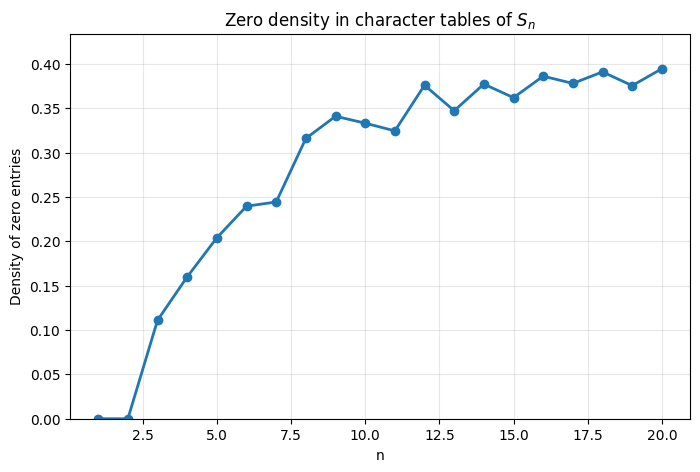

In [17]:
plot_results = sorted(results, key=lambda item: item["n"])
xs = [item["n"] for item in plot_results]
ys = [item["density"] for item in plot_results]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, ys, marker="o", linewidth=2)
ax.set_xlabel("n")
ax.set_ylabel("Density of zero entries")
ax.set_title("Zero density in character tables of $S_n$")
ax.set_ylim(0, max(ys) * 1.1 if ys else 1)
ax.grid(True, alpha=0.3)

for item in plot_results:
    label = "S40 CSV" if item["n"] == 40 and item.get("source") == "csv" else None
    if label:
        ax.annotate(label, (item["n"], item["density"]), xytext=(6, 6), textcoords="offset points")

plt.show()

## Data table

In [14]:
for item in plot_results:
    print(
        f"n={item['n']:>2} source={item['source']:<8} "
        f"zero_density={item['density']:.8f} "
        f"zeros={item['zero_count']} total={item['total_count']}"
    )

n= 1 source=computed zero_density=0.00000000 zeros=0 total=1
n= 2 source=computed zero_density=0.00000000 zeros=0 total=4
n= 3 source=computed zero_density=0.11111111 zeros=1 total=9
n= 4 source=computed zero_density=0.16000000 zeros=4 total=25
n= 5 source=computed zero_density=0.20408163 zeros=10 total=49
n= 6 source=computed zero_density=0.23966942 zeros=29 total=121
n= 7 source=computed zero_density=0.24444444 zeros=55 total=225
n= 8 source=computed zero_density=0.31611570 zeros=153 total=484
n= 9 source=computed zero_density=0.34111111 zeros=307 total=900
n=10 source=computed zero_density=0.33333333 zeros=588 total=1764
n=11 source=computed zero_density=0.32461735 zeros=1018 total=3136
n=12 source=computed zero_density=0.37611739 zeros=2230 total=5929
n=13 source=computed zero_density=0.34731889 zeros=3543 total=10201
n=14 source=computed zero_density=0.37739369 zeros=6878 total=18225
n=40 source=csv      zero_density=0.36039248 zeros=502432617 total=1394126244
